# Analysis: Impact of Input Cell Amount on Growth Rate

This notebook analyzes the relationship between the starting volume of cells and the resulting growth rate, using data from `PLT12V3H4WNRSR6CWJ7A72ODORU7EI_growth.csv`.
We treat the input cell volume as a discrete **categorical** variable.

**Experimental Design:**
- Column 1: 100 µL starting volume
- Column 2: 90 µL starting volume
- ...
- Column 10: 10 µL starting volume


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Preprocess Data
We extract the column number (1 to 10) from each well (e.g., A1, B10) to determine the input cell volume and cast it as a category.

In [7]:
# Load the data
data_path = '../data/PLT12V3H4WNRSR6CWJ7A72ODORU7EI_growth.csv'
df = pd.read_csv(data_path)

# Extract the column number to determine the input cell volume
def get_input_volume(well):
    if not isinstance(well, str) or len(well) < 2:
        return np.nan
    try:
        # The column is everything after the first character (the row letter)
        col_num = int(well[1:])
        if 1 <= col_num <= 10:
            # 1 -> 100, 2 -> 90, ..., 10 -> 10
            return f"{110 - (col_num * 10)} µL"
    except ValueError:
        pass
    return np.nan

df['input_cell_volume'] = df['well'].apply(get_input_volume)

# Drop rows with missing volume or missing growth rate
analysis_df = df.dropna(subset=['input_cell_volume', 'growth_rate_per_hr']).copy()

# Enforce a specific categorical order (from highest volume to lowest)
volume_order = [f"{v} µL" for v in range(100, 0, -10)]
analysis_df['input_cell_volume'] = pd.Categorical(
    analysis_df['input_cell_volume'], 
    categories=volume_order, 
    ordered=True
)

print(f"Total valid samples for analysis: {len(analysis_df)}")
display(analysis_df[['well', 'input_cell_volume', 'growth_rate_per_hr']].head())

Total valid samples for analysis: 30


,well,input_cell_volume,growth_rate_per_hr
0,A1,100 µL,0.895778
1,A10,10 µL,0.547396
2,A2,90 µL,0.327932
3,A3,80 µL,0.266073
4,A4,70 µL,0.196467


## 2. Summary Statistics
Let's look at the average growth rate for each categorical input volume.

In [8]:
summary_stats = analysis_df.groupby('input_cell_volume')['growth_rate_per_hr'].agg(
    mean_growth_rate='mean',
    std_dev='std',
    sample_count='count'
)

display(summary_stats)

/var/folders/nr/m1fx9w0n1sx97898r75mspdc0000gp/T/ipykernel_47994/3416623036.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = analysis_df.groupby('input_cell_volume')['growth_rate_per_hr'].agg(


,mean_growth_rate,std_dev,sample_count
input_cell_volume,,,
100 µL,0.500388,0.345208,3
90 µL,0.338221,0.149451,3
80 µL,0.256965,0.022603,3
70 µL,0.196026,0.006488,3
60 µL,0.186013,0.013018,3
50 µL,0.237431,0.047494,3
40 µL,0.251407,0.011383,3
30 µL,0.415095,0.191975,3
20 µL,0.539403,0.021762,3


## 3. Statistical Analysis (ANOVA)
Since we are treating input volume as a categorical variable, we use a One-Way ANOVA to test if there are statistically significant differences in the mean growth rate across the different input volumes.

In [9]:
# Fit OLS model treating input_cell_volume as categorical
model = ols('growth_rate_per_hr ~ C(input_cell_volume)', data=analysis_df).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

display(anova_table)

p_value = anova_table.loc['C(input_cell_volume)', 'PR(>F)']
print(f"\nANOVA P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Result: STATISTICALLY SIGNIFICANT")
    print("There is a significant difference in growth rates between at least two volume groups.")
else:
    print("Result: NOT STATISTICALLY SIGNIFICANT")
    print("There is no evidence of a significant difference in growth rates across the volume groups.")

,sum_sq,df,F,PR(>F)
C(input_cell_volume),0.543453,9.0,3.316391,0.012236
Residual,0.364153,20.0,NaN,NaN



ANOVA P-value: 1.2236e-02
Result: STATISTICALLY SIGNIFICANT
There is a significant difference in growth rates between at least two volume groups.


## 4. Visualizations
We use categorical plots (box plot and strip plot) to visualize the distribution of growth rates across the different independent groups.

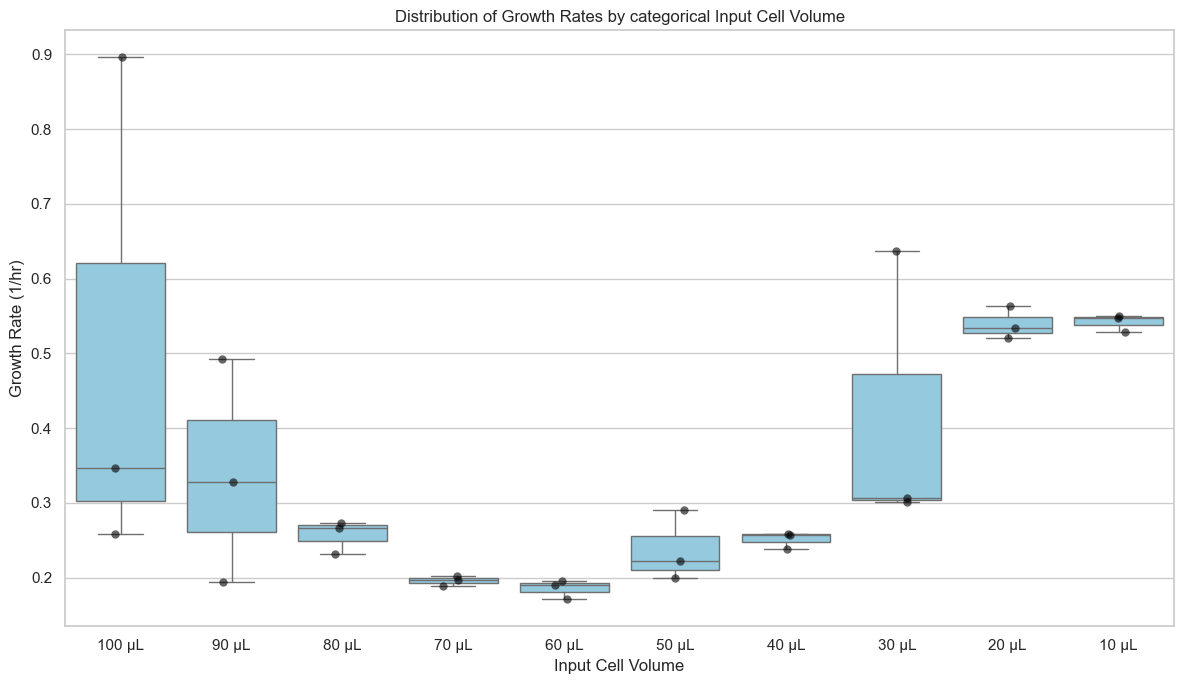

In [10]:
plt.figure(figsize=(12, 7))

# Box plot to show distribution at each categorical volume level
sns.boxplot(
    data=analysis_df, 
    x='input_cell_volume', 
    y='growth_rate_per_hr', 
    color='skyblue'
)

# Strip plot to show the individual underlying data points
sns.stripplot(
    data=analysis_df, 
    x='input_cell_volume', 
    y='growth_rate_per_hr', 
    color='black', 
    alpha=0.6, 
    size=6
)

plt.title('Distribution of Growth Rates by categorical Input Cell Volume')
plt.xlabel('Input Cell Volume')
plt.ylabel('Growth Rate (1/hr)')
plt.tight_layout()
plt.show()